In [1]:
import pandas as pd
# going to import pandas because we are going load a data frame and we are going to plot things on the dataframe
# mostly using seaborn and matplotlib for seaborn we need matplotlib
import seaborn as sns # why sns ? it is a reference to TV show in america in early 2000's called Westwing
#sns stands for sam norman seaborn
# there are lot more pacakges that are named after the other westwing characters
import matplotlib.pyplot as plt # seaborn is based on matplotlib
sns.set(color_codes=True) # adds a nice backgrounf to the graphs
%matplotlib inline 
# this tells python to put the graphs thaat seaborn makes into my jupyter notebook
#if dont have that inline line everytime we make a plot we have to say python that hey python print the plot and dont just create as an objects inside of python that actually show the plot
#if i keep inline instead of creating objects that contains all information of graphs it plots them



In [2]:
a = pd.read_csv('Automobile.csv')


In [3]:
a.head()

,symboling,normalized_losses,make,fuel_type,aspiration,number_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,168,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,168,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,168,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


### first make most basic plot for single variable called univariate variable
# plotting univariate variables
the most convienent way to take a look at univariate distribution in seaborn is distplot() meaning distribution plot or dense plot function . By default this will draw a histogram and fit a kernal density estimate(KDE)

## What is a “bin”?

A **bin** is a range of values used in a histogram.

Example dataset:
52, 55, 57, 60, 61, 61, 65, 70


Suppose we create bins of width 10:

| Bin   | Values inside  | Count |
| ----- | -------------- | ----- |
| 50–59 | 52, 55, 57     | 3     |
| 60–69 | 60, 61, 61, 65 | 4     |
| 70–79 | 70             | 1     |

A histogram draws one bar per bin.

So bins are basically:

> “Buckets” that group nearby values together.

---

## What is a “bump” in KDE?

In Kernel Density Estimation, instead of putting data into buckets, we place a small smooth curve around every data point.

That small curve is the **bump** (kernel).

For example, for a point at 60:


           /\
         /    \
-------60-------

This little hill:

* is highest at the data point,
* decreases smoothly away from it,
* contributes probability around nearby values.

If you have many points, you add all bumps together.

Example:


Point 55:      /\

Point 60:           /\

Point 61:            /\

Combined:     /\/\/\/\__


The final smooth curve is the KDE.

---

## Key Difference

### Histogram

Uses bins:


|■■■|■■■■|■|


### KDE

Uses smooth bumps:


      /\___/\__
 ___/          \__


---

## Simple Analogy

Imagine people standing in a field.

### Histogram

You divide the field into fenced sections and count people in each section.

### KDE

Every person shines a soft flashlight around themselves.
Where many flashlights overlap, the area becomes brighter.

That brightness forms the density curve.


/var/folders/lf/j6lhwfl96ssgpp9bdtfm9r640000gn/T/ipykernel_1084/3360871958.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a['highway_mpg']);


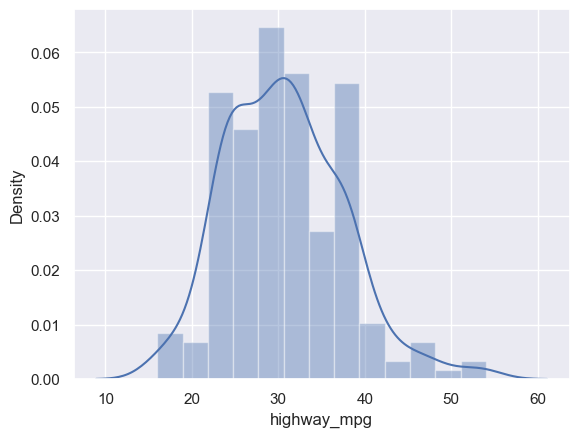

In [4]:
sns.distplot(a['highway_mpg']);
# the reason there is semicolon is the inline is saying that dont create the objects just plot them
# kde gives continuous line by calulatin each bar height and width


/var/folders/lf/j6lhwfl96ssgpp9bdtfm9r640000gn/T/ipykernel_1084/1571687347.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a['city_mpg'],kde =False,rug = True)


<Axes: xlabel='city_mpg'>

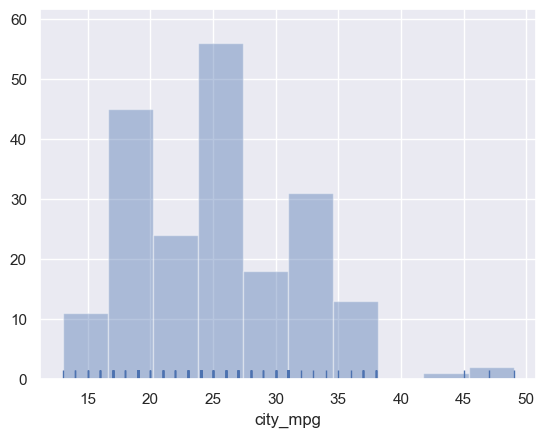

In [5]:
# we can turn the kde off and bklue littke blue tick mark on x-axis for every data point with rug
sns.distplot(a['city_mpg'],kde =False,rug = True)

# Plotting bivariate variables
useful to visualize relationship between 2 variables . use jointplot() function that creates a scatterplot pf 2 variables along with the histograms

`sns.jointplot()` from Seaborn creates a plot that shows:

1. the relationship between two variables, and
2. the distribution of each variable individually.

Your code:

sns.jointplot(x=a['engine_size'], y=a['horsepower']);

means:

* x-axis → `engine_size`
* y-axis → `horsepower`

So it visualizes how engine size and horsepower are related.


## What the plot contains

A jointplot has 3 parts:

       Histogram/KDE of horsepower
                ↑
                |
   Scatter plot |
                |
----------------+------------→
                |
     Histogram/KDE of engine_size


### Center plot

Usually a **scatter plot**:

* each dot = one car
* shows correlation between engine size and horsepower

Example:

* bigger engines → more horsepower
* dots trend upward

---

### Top plot

Distribution of `engine_size`

Shows:

* common engine sizes
* spread of values

---

### Right-side plot

Distribution of `horsepower`

Shows:

* common horsepower ranges
* skewness or clusters

---

## Default behavior

By default:
sns.jointplot(...)

creates:

* scatter plot in center
* histograms on margins


`sns.jointplot()` combines all three views into one figure:

* **Center scatter plot**
  Shows relationship between `engine_size` and `horsepower`.
  Each dot = one car/data row.
  If dots move upward, it means:
  bigger engine size → bigger horsepower.

* **Top plot**
  Shows distribution of `engine_size`.
  Helps you see:

  * which engine sizes occur most,
  * how spread out they are.

* **Right-side plot**
  Shows distribution of `horsepower`.
  Helps identify:

  * common horsepower values,
  * skewness,
  * clusters,
  * unusual values.

## Skewness

Skewness means the data is **not symmetric** — one side stretches longer.

### Right-skewed

Most values are small, but a few very large values exist.

```text id="3vb79w"
■■■■■■■□□□
```

Example:

* most cars have 100–150 horsepower
* a few sports cars have 500 horsepower

Tail goes to the **right**.

---

### Left-skewed

Most values are large, but a few very small values exist.

```text id="r3ubwy"
□□□■■■■■■■
```

Tail goes to the **left**.

---

## Clusters

Clusters are groups of data points gathered together.

Example:

* one group of cars around 100 HP
* another around 300 HP

This may indicate different categories:

* regular cars
* sports cars

In a scatter plot, clusters look like separate bunches of dots.

---

## Unusual values (Outliers)

These are values far away from most other data points.

Example:

* most cars have horsepower between 100–250
* one car has 1000 horsepower

That point is an outlier.

Outliers may indicate:

* rare cases,
* errors,
* or special observations.


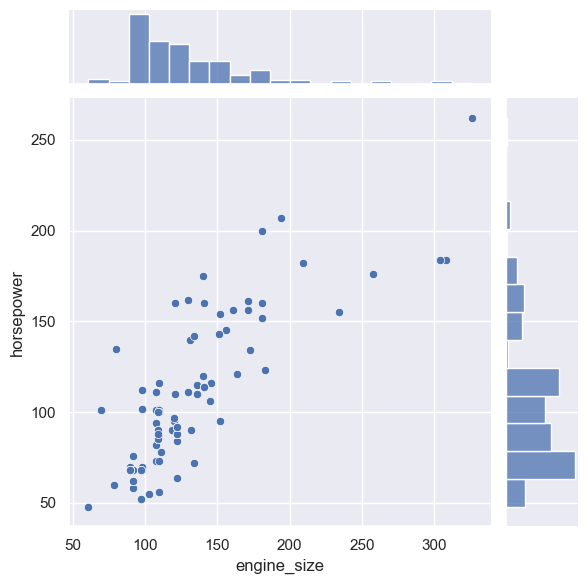

In [6]:
sns.jointplot(x=a['engine_size'], y=a['horsepower']);

# Hex Bin Plots
We can make a hex bin plot that breaks the 2D area into hexagons and the number of points in each hexagon determines the color


sns.jointplot(x=a['engine_size'], y=a['horsepower'], kind="hex")


creates a **hexbin plot** instead of a normal scatter plot.

Instead of showing individual dots, it:

* divides the graph into small hexagon cells,
* counts how many data points fall inside each hexagon.

So areas with many points become more filled/darker.

---

## Why use `kind="hex"`?

Useful when you have many data points.

A scatter plot can become overcrowded because dots overlap.

Hexbin solves this by showing **density of points**.

---

## What it shows

* Dense areas → many cars with similar engine size and horsepower
* Sparse areas → fewer cars
* Overall relationship between the variables

Example:

* many cars may cluster around:

  * engine size = 2.0L
  * horsepower = 150

That hexagon becomes darker/more intense.


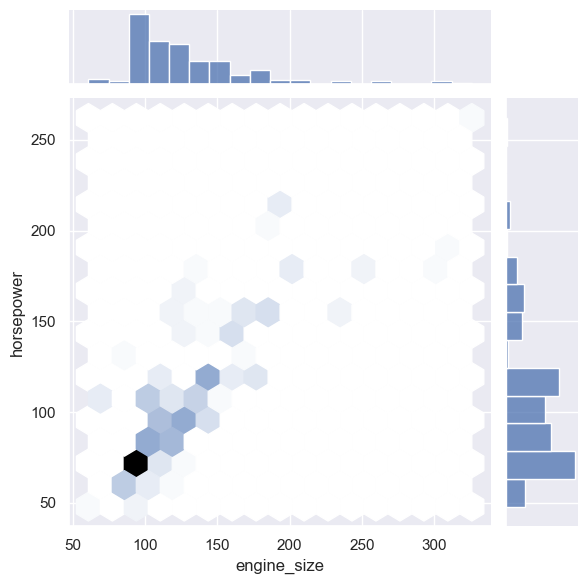

In [7]:
sns.jointplot(x=a['engine_size'], y=a['horsepower'], kind="hex");

# Kernel Density Estimation
We can make a 2D estimation of the density also


sns.jointplot(x=a['engine_size'], y=a['horsepower'], kind="kde")


creates a **Kernel Density Estimate (KDE) joint plot**.

Instead of:

* dots (`scatter`)
  or
* hexagons (`hex`),

it draws **smooth density curves** showing where data points are concentrated.

---

## What it shows

* Areas with many data points → denser/darker contours
* Areas with few points → lighter/sparser regions

It looks similar to a topographic map.

---

## In your example

It shows where cars are most commonly found based on:

* `engine_size`
* `horsepower`

Example:

* many cars may be concentrated around:

  * engine size = 2.0
  * horsepower = 150

So KDE draws smooth contour regions there.

---

## Side plots

Top and right side also become smooth KDE distribution curves instead of histograms.

So you get:

* smooth distribution of `engine_size`
* smooth distribution of `horsepower`
* smooth joint density in the center

---

## Why use KDE?

Useful for:

* understanding overall data shape,
* finding dense regions,
* seeing patterns smoothly without individual dots.


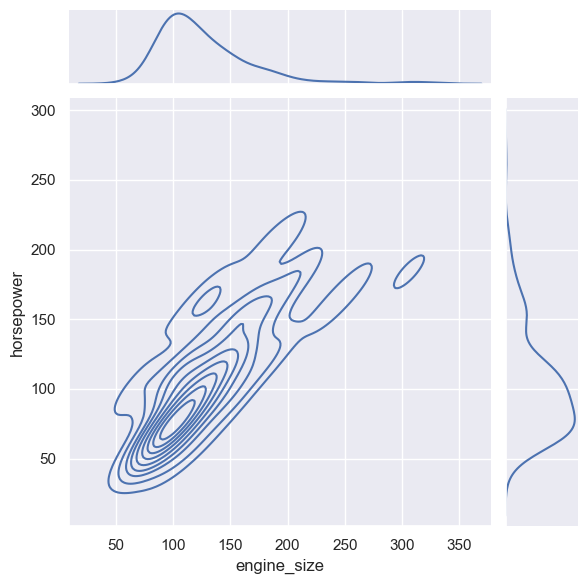

In [8]:
sns.jointplot(x=a['engine_size'], y=a['horsepower'], kind="kde");

# Visualizing pairwise relationships in a dataset
To plot multiple pairwise scatterplots in a dataset, you can use the pairplot() function. This creates a matrix of axes and shows the relationship for each pair of columns in a DataFrame, it also draws the histogram of each variable on the diagonal Axes:

Be careful about toggle scrolling in the cell menu!!!


sns.pairplot(a[['normalized_losses', 'engine_size', 'horsepower']])


creates plots for **every pair of variables** in the given columns.

Here the variables are:

* `normalized_losses`
* `engine_size`
* `horsepower`

---

## What it does

It automatically creates:

* scatter plots between every pair of columns,
* and distribution plots on the diagonal.

---

## Example layout


                    engine_size   horsepower
normalized_losses      plot         plot

engine_size            plot         plot

horsepower             plot         plot


---

## What you can learn

It helps you quickly see:

* correlations,
* trends,
* clusters,
* outliers,
* distributions of each feature.

Example:

* `engine_size` vs `horsepower`
  may show strong positive correlation.

---

## Diagonal plots

The diagonal usually shows:

* histograms
  or
* KDE distributions

for each individual variable.


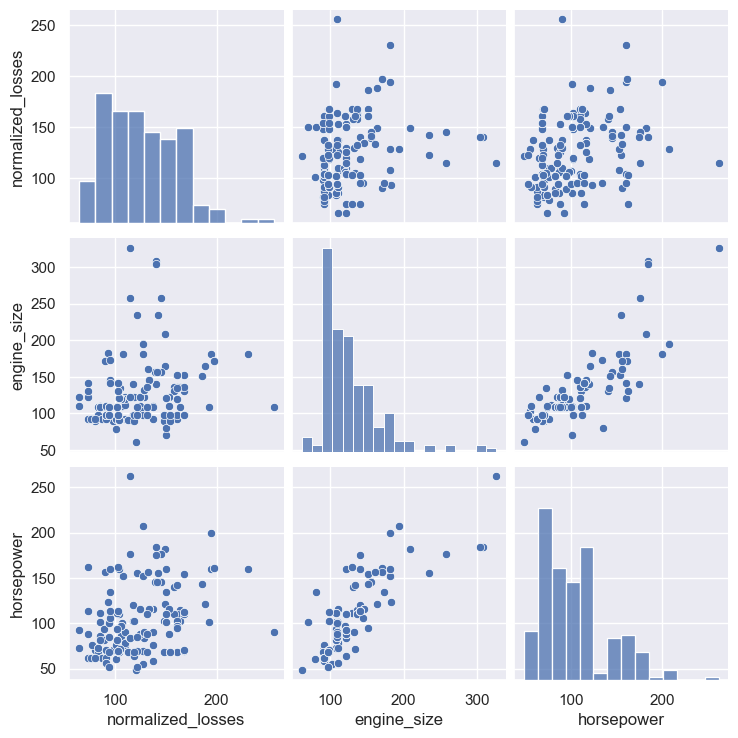

In [9]:
sns.pairplot(a[['normalized_losses', 'engine_size', 'horsepower']]);

# Plotting categorical data

In a strip plot, the scatterplot points will usually overlap. This makes it difficult to see the full distribution of data. One easy solution is to adjust the positions (only along the categorical axis) using “jitter"

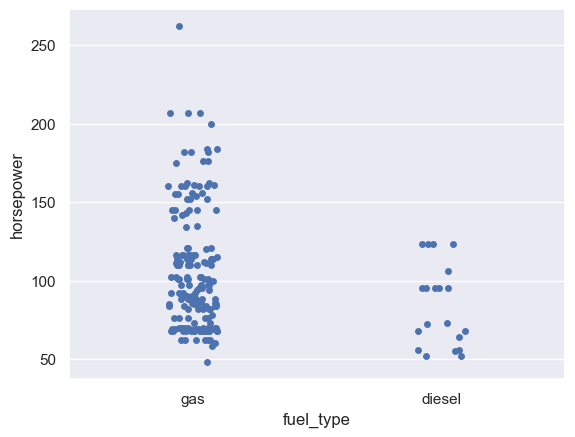

In [12]:
sns.stripplot(x=a['fuel_type'], y=a['horsepower'], jitter=True);
# if i keep jitter = false then it comes as a straight line indicating single values and density will be more so it is hard to define

A different approach would be to use the function swarmplot(), which positions each scatterplot point on the categorical axis and avoids overlapping points:

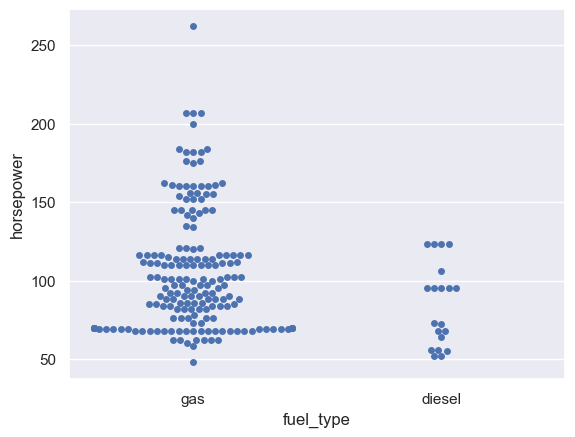

In [25]:
sns.swarmplot(x=a['fuel_type'], y=a['horsepower']); # tells that how far we have to spread these thing so that data pooints doesnot overlap

# Boxplots
Another common graph is a boxplot(). This kind of plot shows the three quartile values of the distribution along with extreme values. The “whiskers” extend to points that lie within 1.5 IQRs of the lower and upper quartile, and then observations that fall outside this range are displayed independently.

An **outlier** is a data value that is **very different from the rest of the data** (unusually high or unusually low).

In a **box plot**, an outlier is a point that lies **outside the whiskers**.

It is identified using:

\text{Lower Limit}=Q_1-1.5(IQR) \quad \text{Upper Limit}=Q_3+1.5(IQR)

* If a value is **less than the lower limit**, it is an outlier.
* If a value is **greater than the upper limit**, it is an outlier.

### Example from your graph:

For **two-door cars**:

* Q1 ≈ 70
* Q3 ≈ 130
* IQR = 60

Upper limit:
[
130 + (1.5 \times 60) = 220
]

The point around **260 horsepower** is **greater than 220**, so it is an **outlier**.

### Simple definition for notebook:

> “An outlier is a data point that is significantly different from other values and lies outside the whiskers of a box plot.”


You can describe it like this using **IQR and whiskers formula**:

### Box Plot Description Using Q1, Q3, IQR, and Whiskers

The box plot contains **Q1 (First Quartile), Median, and Q3 (Third Quartile)**.

* **Q1** represents the **25th percentile** (25% of data lies below this value).
* **Median (Q2)** represents the **50th percentile** (middle value).
* **Q3** represents the **75th percentile** (75% of data lies below this value).

The **Interquartile Range (IQR)** is calculated as:

[
IQR = Q3 - Q1
]

IQR = Q_3 - Q_1

The **whiskers** are calculated using:

* **Lower whisker** = **Q1 − 1.5 × IQR**
* **Upper whisker** = **Q3 + 1.5 × IQR**

\text{Lower Whisker}=Q_1-1.5(IQR) \quad \text{Upper Whisker}=Q_3+1.5(IQR)

For this graph:

### Two-door Cars

* **Q1 ≈ 70**
* **Q3 ≈ 130**
* **IQR = 130 − 70 = 60**

Lower whisker:
[
70 - (1.5 \times 60)= -20
]

Upper whisker:
[
130 + (1.5 \times 60)= 220
]

Values outside this range are considered **outliers** (for example, the point around **260 hp**).

### Four-door Cars

* **Q1 ≈ 73**
* **Q3 ≈ 113**
* **IQR = 113 − 73 = 40**

Lower whisker:
[
73 - (1.5 \times 40)= 13
]

Upper whisker:
[
113 + (1.5 \times 40)= 173
]

Points above this range (around **180 hp**) are treated as **outliers**.

You can write in simple words:

> “In a box plot, the whiskers are calculated using Q1 − 1.5 × IQR and Q3 + 1.5 × IQR, where IQR = Q3 − Q1. Any values outside the whiskers are considered outliers.”


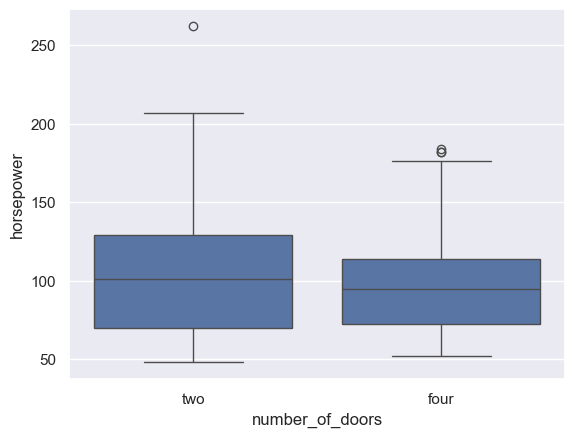

In [27]:
sns.boxplot(x=a['number_of_doors'], y=a['horsepower']);




### Description of the Box Plot Using Quartiles and Whiskers

#### **Two-door Cars**

* **Q1 (First Quartile):** Around **70 horsepower**
  → This means **25% of two-door cars have horsepower below 70**.

* **Median (Q2):** Around **100 horsepower**
  → This represents the **middle value**, meaning **50% of the cars have horsepower below 100 and 50% above 100**.

* **Q3 (Third Quartile):** Around **130 horsepower**
  → This means **75% of two-door cars have horsepower below 130**.

* **Whiskers:**

  * Lower whisker is around **48 horsepower** (minimum non-outlier value).
  * Upper whisker is around **207 horsepower** (maximum non-outlier value).

* **Outlier:**
  One point above **260 horsepower** indicates an **unusually high horsepower car**.

---

#### **Four-door Cars**

* **Q1 (First Quartile):** Around **73 horsepower**
  → **25% of four-door cars have horsepower below 73**.

* **Median (Q2):** Around **95 horsepower**
  → The middle horsepower value is around **95**.

* **Q3 (Third Quartile):** Around **113 horsepower**
  → **75% of four-door cars have horsepower below 113**.

* **Whiskers:**

  * Lower whisker is around **51 horsepower**.
  * Upper whisker is around **176 horsepower**.

* **Outliers:**
  A few cars above **180 horsepower** are present, showing **high horsepower exceptions**.

In your diagram, it looks **slightly right-skewed (positively skewed)**, especially for **two-door cars**.

### How to identify skewness in a box plot:

* **Right-skewed (Positive skew)** → Upper whisker is longer and outliers are on the **right/high-value side**.
* **Left-skewed (Negative skew)** → Lower whisker is longer and outliers are on the **left/low-value side**.
* **Symmetric** → Both whiskers are almost equal and median is near the center.

For your box plot:

✅ **Two-door cars → Right-skewed**
Reason:

* Upper whisker is longer.
* There is a high-value outlier (~260 hp) on the right side.
* Data spreads more toward higher horsepower.

✅ **Four-door cars → Slightly right-skewed**
Reason:

* Upper whisker is a bit longer.
* Outliers are on the higher horsepower side (~180 hp).

You can write:

> “The box plot is **right-skewed (positively skewed)** because the upper whiskers are longer and outliers are present on the higher-value side.”


### Final Observation

> The box plot shows that **two-door cars have a higher spread in horsepower and slightly higher median horsepower than four-door cars.** The whiskers indicate the range of normal values, while the outliers represent cars with unusually high horsepower.


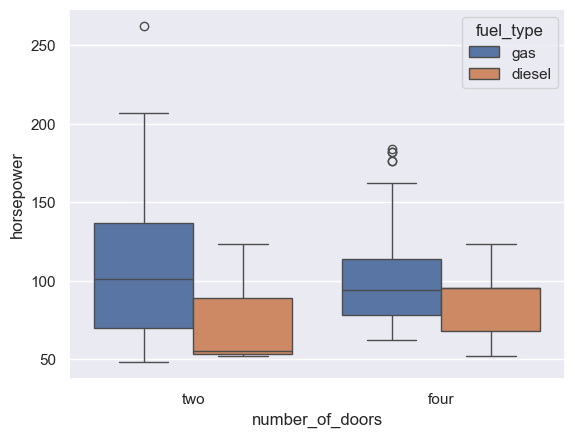

In [26]:
sns.boxplot(x=a['number_of_doors'], y=a['horsepower'], hue=a['fuel_type']);

# Bar plots
We can plot the mean of a a dataset, separated in categories using the barplot() function. When there are multiple observations in each category, it uses bootstrapping to compute a confidence interval around the estimate and plots that using error bars:

Bar plots start at 0, which can sometimes be practical if zero is a number you want to compare to

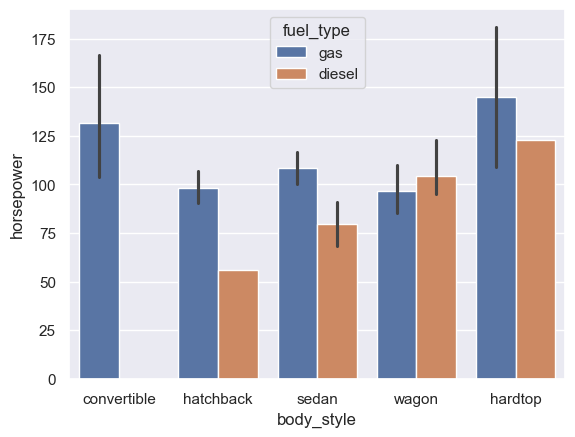

In [28]:
sns.barplot(x=a['body_style'], y=a['horsepower'], hue=a['fuel_type']); # plots mean of the horsepower

A special case for the bar plot is when you want to show the number of observations in each category rather than computing the mean of a second variable. This is similar to a histogram over a categorical, rather than quantitative, variable. In seaborn, it’s easy to do so with the countplot() function:

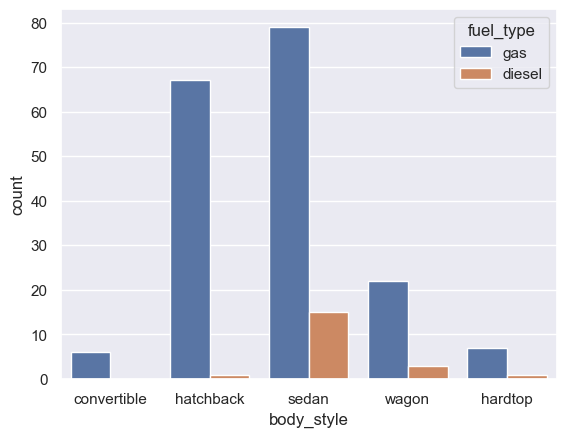

In [30]:
sns.countplot(x=a['body_style'],hue=a['fuel_type']);#number of cars in each body type use countplot
# how many cars in each of these categories

# Point plots
An alternative style for visualizing the same information is offered by the pointplot() function. This function also encodes the value of the estimate with height on the other axis, but rather than show a full bar it just plots the point estimate and confidence interval. Additionally, pointplot connects points from the same hue category. This makes it easy to see how the main relationship is changing as a function of a second variable, because your eyes are quite good at picking up on differences of slopes:

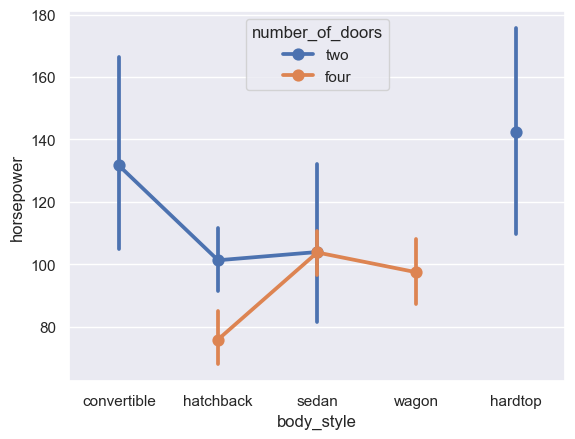

In [21]:
sns.pointplot(x=a['body_style'], y=a['horsepower'], hue=a['number_of_doors']);


# Drawing multi-panel categorical plots

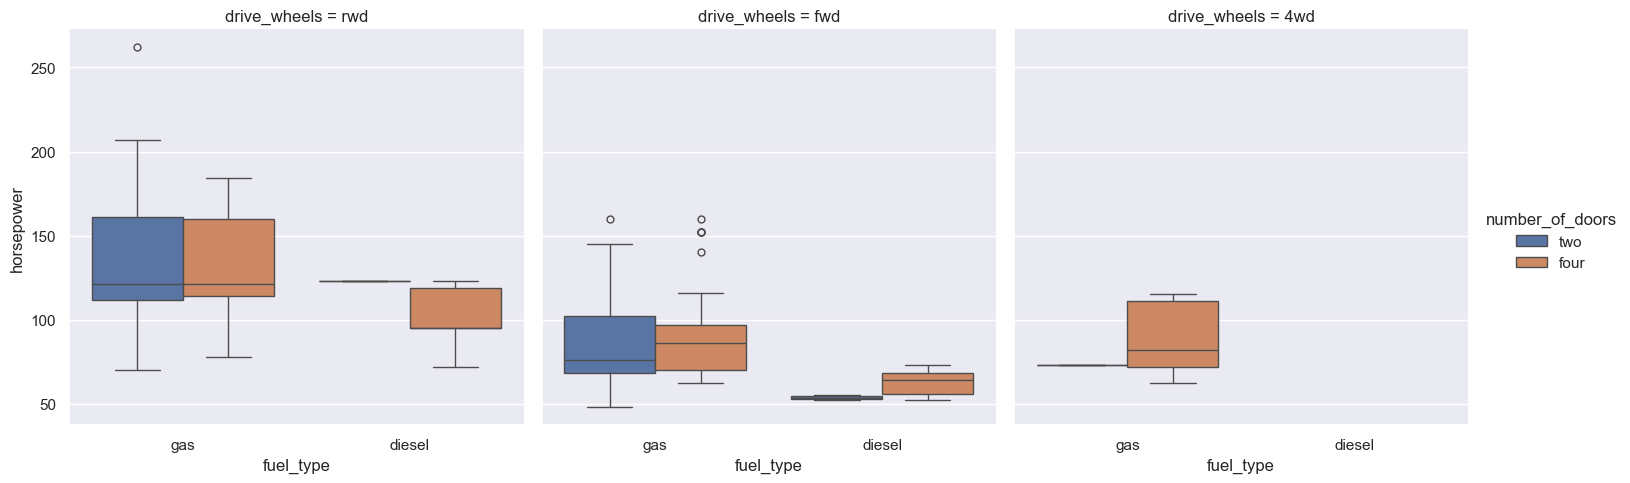

In [22]:
sns.catplot(x="fuel_type",
               y = "horsepower",
               hue="number_of_doors", 
               col="drive_wheels", 
               data=a, 
               kind="box");

various types of kind input : {point, bar, count, box, violin, strip}

# Function to draw linear regression models
lmplot() is one of the most widely used function to quickly plot the Linear Relationship between 2 variables

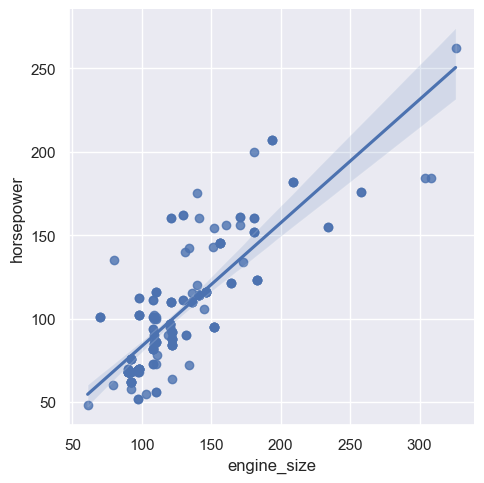

In [23]:
sns.lmplot(y="horsepower", x="engine_size", data=a);

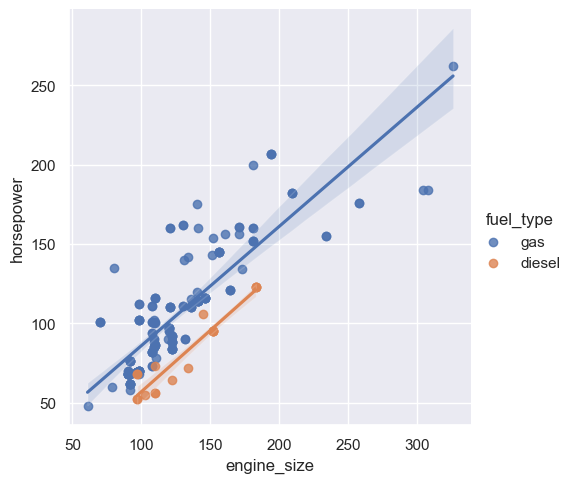

In [24]:
sns.lmplot(y="horsepower", x="engine_size",hue="fuel_type", data=a);